# Extração de landmarks com MediaPipe Holistic — KSL Dataset

Este notebook percorre a estrutura do KSL no formato:

```text
ksl/
  01/
    00_01.MP4
    01_01.MP4
    ...
    19_01.MP4
  02/
    00_02.MP4
    ...
  ...
  77/
    00_77.MP4
    ...
    19_77.MP4
```

Para cada vídeo RGB, ele extrai landmarks com **MediaPipe Holistic** e salva um arquivo `.parquet` por vídeo em formato **long**.

1. percorrer automaticamente a estrutura do KSL (`ksl/01/00_01.MP4` ... `ksl/77/19_77.MP4`);
2. extrair landmarks com **MediaPipe Holistic** a partir dos vídeos RGB;
3. salvar um arquivo de landmarks por vídeo em formato `long`;
4. carregar os metadados de classe do arquivo `ksl_class_label.p`;
5. gerar `metadata_ksl.csv` com `sign_id`, `sign`, `interpreter` e caminhos dos arquivos;
6. juntar todos os vídeos em um único CSV `wide`, similar ao formato do MINDS, com uma linha por frame.

CSV final esperado:

```text
sign | sign_id | interpreter | video_name | frame_id | hand_0_0_x | hand_0_0_y | hand_0_0_z | ... | missing_hand | missing_face
```

Por padrão, cada frame terá até **543 pontos**:

- `face`: 468 landmarks;
- `pose`: 33 landmarks;
- `hand_0`: 21 landmarks, mão esquerda;
- `hand_1`: 21 landmarks, mão direita.

Quando uma parte não é detectada em um frame, o notebook salva os pontos esperados com `NaN`. Isso mantém a estrutura regular e facilita imputação depois.

## 1. Instalação

In [1]:
# Em Colab/Jupyter, rode esta célula uma vez.
# Se estiver em notebook local e já tiver os pacotes instalados, pode pular.

%pip install -q mediapipe opencv-python-headless pandas pyarrow tqdm matplotlib

Note: you may need to restart the kernel to use updated packages.


## 2. Imports

In [9]:
import pickle
from pathlib import Path
import json
import time
import cv2
import numpy as np
import pandas as pd
from tqdm.auto import tqdm
import matplotlib.pyplot as plt

import mediapipe as mp

## 3. Configuração de caminhos

In [45]:
# ============================================================================
# AJUSTE AQUI
# ============================================================================

# Pasta onde o notebook está rodando
BASE_DIR = Path.cwd()

# ---------------------------------------------------------------------------
# Dataset KSL
# ---------------------------------------------------------------------------
# Estrutura esperada:
#
# datasets/
#   ksl/
#     01/
#       00_01.MP4
#       01_01.MP4
#       ...
#     77/
#       19_77.MP4
#     ksl_class_label.p
#
# Se sua pasta KSL estiver em outro lugar, altere apenas esta linha.
KSL_ROOT = BASE_DIR / "datasets" / "ksl"

# ---------------------------------------------------------------------------
# Arquivo de labels do KSL
# ---------------------------------------------------------------------------
# O arquivo ksl_class_label.p pode estar dentro da pasta KSL.
CLASS_LABEL_PATH = KSL_ROOT / "ksl_class_label.p"

# Se ele estiver na mesma pasta do notebook, use esta linha no lugar da de cima:
# CLASS_LABEL_PATH = BASE_DIR / "ksl_class_label.p"

# ---------------------------------------------------------------------------
# Pasta de saída
# ---------------------------------------------------------------------------
# Aqui serão salvos todos os resultados gerados pelo notebook.
# Não use /content se estiver rodando local no Mac.
OUTPUT_ROOT = BASE_DIR / "ksl_mediapipe"

# Dentro de OUTPUT_ROOT serão criados/salvos:
#
# ksl_mediapipe/
#   metadata_ksl.csv
#   ksl_mediapipe_all_videos_wide.csv
#   landmarks/
#     01__00_01.parquet
#     01__01_01.parquet
#     ...
LANDMARKS_DIR = OUTPUT_ROOT / "landmarks"

METADATA_PATH = OUTPUT_ROOT / "metadata_ksl.csv"
FINAL_WIDE_CSV_PATH = OUTPUT_ROOT / "ksl_mediapipe_all_videos_wide.csv"

# ---------------------------------------------------------------------------
# Formato dos arquivos individuais de landmarks
# ---------------------------------------------------------------------------
# "parquet" é recomendado porque ocupa menos espaço e carrega mais rápido.
SAVE_FORMAT = "parquet"  # opções: "parquet" ou "csv"

# ---------------------------------------------------------------------------
# Configurações do MediaPipe
# ---------------------------------------------------------------------------
# No seu artigo, foi usado 0.4 para detection e tracking.
MIN_DETECTION_CONFIDENCE = 0.4
MIN_TRACKING_CONFIDENCE = 0.4

# ---------------------------------------------------------------------------
# Tratamento de landmarks ausentes
# ---------------------------------------------------------------------------
# False mantém NaN no CSV final wide.
# True substitui NaN por 0.0, ficando mais parecido com o formato do MINDS.
#
# Recomendação:
# - False para análise/imputação correta;
# - True apenas se o código de treino exigir 0.0.
FILL_MISSING_WITH_0 = False

# ---------------------------------------------------------------------------
# Controle de reprocessamento
# ---------------------------------------------------------------------------
# Se True, não reprocessa vídeos cujo arquivo de saída já existe.
SKIP_EXISTING = True

# ---------------------------------------------------------------------------
# Extensões aceitas
# ---------------------------------------------------------------------------
VIDEO_EXTENSIONS = {".mp4", ".avi", ".mov", ".mkv", ".webm"}

# ============================================================================
# CRIAÇÃO DAS PASTAS
# ============================================================================

LANDMARKS_DIR.mkdir(parents=True, exist_ok=True)

# ============================================================================
# CHECAGENS
# ============================================================================

print("BASE_DIR:", BASE_DIR)
print("KSL_ROOT:", KSL_ROOT)
print("KSL_ROOT existe?", KSL_ROOT.exists())

print("CLASS_LABEL_PATH:", CLASS_LABEL_PATH)
print("CLASS_LABEL_PATH existe?", CLASS_LABEL_PATH.exists())

print("OUTPUT_ROOT:", OUTPUT_ROOT)
print("LANDMARKS_DIR:", LANDMARKS_DIR)
print("METADATA_PATH:", METADATA_PATH)
print("FINAL_WIDE_CSV_PATH:", FINAL_WIDE_CSV_PATH)

# Evita repetir sem querer o erro do Colab em ambiente local
if "/content" in str(OUTPUT_ROOT):
    raise ValueError(
        "OUTPUT_ROOT ainda aponta para /content. "
        "Você está rodando localmente no Mac, então use BASE_DIR ou Path.home()."
    )

BASE_DIR: /Users/dani/Projects/islr-subset
KSL_ROOT: /Users/dani/Projects/islr-subset/datasets/ksl
KSL_ROOT existe? True
CLASS_LABEL_PATH: /Users/dani/Projects/islr-subset/datasets/ksl/ksl_class_label.p
CLASS_LABEL_PATH existe? True
OUTPUT_ROOT: /Users/dani/Projects/islr-subset/ksl_mediapipe
LANDMARKS_DIR: /Users/dani/Projects/islr-subset/ksl_mediapipe/landmarks
METADATA_PATH: /Users/dani/Projects/islr-subset/ksl_mediapipe/metadata_ksl.csv
FINAL_WIDE_CSV_PATH: /Users/dani/Projects/islr-subset/ksl_mediapipe/ksl_mediapipe_all_videos_wide.csv


### 3.1 Labels/metadados do KSL

O arquivo `ksl_class_label.p` mapeia o ID da classe para o nome textual do sinal.

Exemplo:

```text
1  -> hi
2  -> what
77 -> care
```

O notebook tenta carregar esse arquivo a partir de `CLASS_LABEL_PATH`. Se ele não estiver disponível, usa o dicionário embutido abaixo.

In [10]:
# Dicionário embutido a partir do arquivo ksl_class_label.p.
KSL_CLASS_LABELS_FALLBACK = {0: ' ',
 1: 'hi',
 2: 'what',
 3: 'meat',
 4: 'bi bim rice',
 5: 'glad',
 6: 'hobby',
 7: 'me',
 8: 'movie',
 9: 'face',
 10: 'see',
 11: 'name',
 12: 'read',
 13: 'thank',
 14: 'equal',
 15: 'sorry',
 16: 'eat',
 17: 'fine',
 18: 'do effort',
 19: 'next',
 20: 'age',
 21: 'again',
 22: 'how many',
 23: 'day',
 24: 'good, nice',
 25: 'when',
 26: 'we',
 27: 'subway',
 28: 'be friendly',
 29: 'bus',
 30: 'ride',
 31: 'cell phone',
 32: 'where',
 33: 'number',
 34: 'location',
 35: 'guide',
 36: 'responsibility',
 37: 'who',
 38: 'arrive',
 39: 'family',
 40: 'time',
 41: 'introduction',
 42: 'recieve',
 43: 'please?',
 44: 'walk',
 45: 'parents',
 46: '10 minutes',
 47: 'sister',
 48: 'study',
 49: 'human',
 50: 'now',
 51: 'special',
 52: 'yesterday',
 53: 'education',
 54: 'test',
 55: 'end',
 56: 'you',
 57: 'worried_about',
 58: 'marry',
 59: 'effort',
 60: 'no',
 61: 'sweat',
 62: 'yet',
 63: 'finally',
 64: 'born',
 65: 'success',
 66: 'favor',
 67: 'Seoul',
 68: 'dinner',
 69: 'experience',
 70: 'invite',
 71: 'food',
 72: 'want',
 73: 'visit',
 74: 'one hour',
 75: 'far',
 76: 'good',
 77: 'care',
 78: ' ',
 79: ' ',
 80: ' ',
 81: ' ',
 82: ' ',
 83: ' ',
 84: ' ',
 85: ' ',
 86: ' ',
 87: ' ',
 88: ' ',
 89: ' ',
 90: ' ',
 91: ' ',
 92: ' ',
 93: ' ',
 94: ' ',
 95: ' ',
 96: ' ',
 97: ' ',
 98: ' ',
 99: ' ',
 100: ' '}


def load_ksl_class_labels(class_label_path=None):
    class_label_path = Path(class_label_path) if class_label_path is not None else None

    if class_label_path is not None and class_label_path.exists():
        with open(class_label_path, "rb") as f:
            labels = pickle.load(f)
        print(f"Labels carregados de: {class_label_path}")
        return labels

    print("Arquivo de labels não encontrado. Usando dicionário embutido no notebook.")
    return KSL_CLASS_LABELS_FALLBACK.copy()


KSL_CLASS_LABELS = load_ksl_class_labels(CLASS_LABEL_PATH)

print(type(KSL_CLASS_LABELS), len(KSL_CLASS_LABELS))
print(list(KSL_CLASS_LABELS.items())[:10])

Labels carregados de: /Users/dani/Projects/islr-subset/datasets/ksl/ksl_class_label.p
<class 'dict'> 101
[(0, ' '), (1, 'hi'), (2, 'what'), (3, 'meat'), (4, 'bi bim rice'), (5, 'glad'), (6, 'hobby'), (7, 'me'), (8, 'movie'), (9, 'face')]


### 3.2 Opcional: montar Google Drive no Colab

In [ ]:
# Rode esta célula somente se os vídeos estiverem no Google Drive.
# Depois ajuste KSL_ROOT e OUTPUT_ROOT na célula anterior.

# from google.colab import drive
# drive.mount("/content/drive")

## 4. Definições do MediaPipe

In [11]:
mp_holistic = mp.solutions.holistic
mp_drawing = mp.solutions.drawing_utils
mp_drawing_styles = mp.solutions.drawing_styles

# Quantidade esperada por grupo no MediaPipe Holistic.
# hand_0 = mão esquerda
# hand_1 = mão direita
LANDMARK_GROUPS = {
    "face": 468,
    "pose": 33,
    "hand_0": 21,
    "hand_1": 21,
}


def get_landmark_list(results, landmark_type):
    """
    Retorna a lista de landmarks correspondente ao tipo.
    """
    if landmark_type == "face":
        return results.face_landmarks
    if landmark_type == "pose":
        return results.pose_landmarks
    if landmark_type == "hand_0":
        return results.left_hand_landmarks
    if landmark_type == "hand_1":
        return results.right_hand_landmarks

    raise ValueError(f"Tipo de landmark inválido: {landmark_type}")


def landmarks_to_rows(results, frame_id, timestamp_ms, video_name):
    """
    Converte a saída do MediaPipe em linhas long-format.

    Mesmo se uma parte não for detectada, cria linhas com NaN para manter
    a mesma quantidade de landmarks por frame.
    """
    rows = []

    for landmark_type, expected_count in LANDMARK_GROUPS.items():
        landmark_list = get_landmark_list(results, landmark_type)

        if landmark_list is None:
            for landmark_index in range(expected_count):
                rows.append({
                    "video_name": video_name,
                    "frame_id": frame_id,
                    "timestamp_ms": timestamp_ms,
                    "type": landmark_type,
                    "landmark_index": landmark_index,
                    "x": np.nan,
                    "y": np.nan,
                    "z": np.nan,
                    "visibility": np.nan,
                })
            continue

        landmarks = landmark_list.landmark

        for landmark_index in range(expected_count):
            if landmark_index < len(landmarks):
                lm = landmarks[landmark_index]
                rows.append({
                    "video_name": video_name,
                    "frame_id": frame_id,
                    "timestamp_ms": timestamp_ms,
                    "type": landmark_type,
                    "landmark_index": landmark_index,
                    "x": lm.x,
                    "y": lm.y,
                    "z": lm.z,
                    "visibility": getattr(lm, "visibility", np.nan),
                })
            else:
                rows.append({
                    "video_name": video_name,
                    "frame_id": frame_id,
                    "timestamp_ms": timestamp_ms,
                    "type": landmark_type,
                    "landmark_index": landmark_index,
                    "x": np.nan,
                    "y": np.nan,
                    "z": np.nan,
                    "visibility": np.nan,
                })

    return rows

## 5. Função para extrair landmarks de um vídeo

In [12]:
def extract_mediapipe_from_video(
    video_path,
    output_path,
    min_detection_confidence=0.4,
    min_tracking_confidence=0.4,
    save_format="parquet",
    model_complexity=1,
    refine_face_landmarks=False,
):
    """
    Extrai landmarks MediaPipe Holistic de um vídeo RGB.

    Parâmetros
    ----------
    video_path : str ou Path
        Caminho do vídeo.
    output_path : str ou Path
        Caminho do arquivo de saída (.parquet ou .csv).
    min_detection_confidence : float
        Confiança mínima para detecção.
    min_tracking_confidence : float
        Confiança mínima para tracking.
    save_format : str
        "parquet" ou "csv".
    model_complexity : int
        Complexidade do modelo de pose. Valores comuns: 0, 1, 2.
    refine_face_landmarks : bool
        Se True, refina landmarks de olhos/lábios. Para manter 468 pontos de face,
        deixe False.

    Retorna
    -------
    dict
        Informações de processamento.
    """
    video_path = Path(video_path)
    output_path = Path(output_path)
    output_path.parent.mkdir(parents=True, exist_ok=True)

    cap = cv2.VideoCapture(str(video_path))

    if not cap.isOpened():
        raise RuntimeError(f"Não foi possível abrir o vídeo: {video_path}")

    fps = cap.get(cv2.CAP_PROP_FPS)
    if fps is None or fps <= 0 or np.isnan(fps):
        fps = 30.0

    expected_frame_count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

    all_rows = []
    frame_id = 0
    start_time = time.time()

    with mp_holistic.Holistic(
        static_image_mode=False,
        model_complexity=model_complexity,
        smooth_landmarks=True,
        enable_segmentation=False,
        smooth_segmentation=False,
        refine_face_landmarks=refine_face_landmarks,
        min_detection_confidence=min_detection_confidence,
        min_tracking_confidence=min_tracking_confidence,
    ) as holistic:

        while True:
            success, frame_bgr = cap.read()

            if not success:
                break

            # OpenCV lê BGR; MediaPipe espera RGB.
            frame_rgb = cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2RGB)
            frame_rgb.flags.writeable = False

            results = holistic.process(frame_rgb)

            timestamp_ms = int((frame_id / fps) * 1000)

            rows = landmarks_to_rows(
                results=results,
                frame_id=frame_id,
                timestamp_ms=timestamp_ms,
                video_name=video_path.name,
            )

            all_rows.extend(rows)
            frame_id += 1

    cap.release()

    df = pd.DataFrame(all_rows)

    if save_format == "parquet":
        df.to_parquet(output_path, index=False)
    elif save_format == "csv":
        df.to_csv(output_path, index=False)
    else:
        raise ValueError("save_format deve ser 'parquet' ou 'csv'.")

    elapsed_seconds = time.time() - start_time

    return {
        "video_path": str(video_path),
        "output_path": str(output_path),
        "frames_read": frame_id,
        "expected_frame_count": expected_frame_count,
        "fps": fps,
        "width": width,
        "height": height,
        "rows": len(df),
        "elapsed_seconds": elapsed_seconds,
        "seconds_per_video": elapsed_seconds,
        "seconds_per_frame": elapsed_seconds / frame_id if frame_id > 0 else np.nan,
    }

## 6. Funções específicas para percorrer o KSL

In [13]:
def get_ksl_label(sign_id, class_labels=KSL_CLASS_LABELS):
    try:
        sign_int = int(sign_id)
    except Exception:
        return ""

    label = class_labels.get(sign_int, "")
    if label is None:
        label = ""

    return str(label).strip()


print("Classe 01:", get_ksl_label("01"))
print("Classe 77:", get_ksl_label("77"))


def list_ksl_videos(ksl_root):
    # Percorre recursivamente a pasta KSL e retorna todos os vídeos encontrados.
    # Trata .MP4 e .mp4 igualmente.
    ksl_root = Path(ksl_root)

    videos = [
        path for path in ksl_root.rglob("*")
        if path.is_file() and path.suffix.lower() in VIDEO_EXTENSIONS
    ]

    return sorted(videos)


def parse_ksl_info_from_video_name(video_name, class_labels=KSL_CLASS_LABELS):
    # Exemplo:
    # 00_01.MP4 -> interpreter = 00, sign_id = 01, sign = hi
    # 19_77.MP4 -> interpreter = 19, sign_id = 77, sign = care
    stem = Path(video_name).stem
    parts = stem.split("_")

    if len(parts) >= 2:
        interpreter = parts[0].zfill(2)
        sign_id = parts[1].zfill(2)
    else:
        interpreter = ""
        sign_id = ""

    sign = get_ksl_label(sign_id, class_labels) if sign_id != "" else ""

    return sign_id, sign, interpreter


def parse_ksl_video_info(video_path, class_labels=KSL_CLASS_LABELS):
    # Extrai informações a partir da estrutura do KSL.
    # Exemplo: ksl/01/00_01.MP4
    video_path = Path(video_path)

    sign_folder = video_path.parent.name.zfill(2)
    video_name = video_path.name
    video_stem = video_path.stem

    sign_id_from_name, sign_from_name, interpreter = parse_ksl_info_from_video_name(
        video_name,
        class_labels=class_labels,
    )

    # Preferimos o sign_id do nome do arquivo; se não existir, usa o da pasta.
    sign_id = sign_id_from_name if sign_id_from_name else sign_folder
    sign = get_ksl_label(sign_id, class_labels)

    return {
        "sign_id": sign_id,
        "sign": sign,
        "sign_folder": sign_folder,
        "sign_from_filename": sign_id_from_name,
        "interpreter": interpreter,
        "signer_or_sample_id": interpreter,  # alias para compatibilidade com versões anteriores
        "sequence_id": video_stem,
        "video_name": video_name,
    }


def safe_ksl_output_name(video_path, ksl_root, suffix=".parquet"):
    # Gera um nome único de saída preservando classe + nome do vídeo.
    # Exemplo: ksl/01/00_01.MP4 -> 01__00_01.parquet
    video_path = Path(video_path)
    ksl_root = Path(ksl_root)

    relative = video_path.relative_to(ksl_root).with_suffix("")
    safe_name = "__".join(relative.parts)

    return safe_name + suffix


print(parse_ksl_info_from_video_name("00_01.MP4"))
print(parse_ksl_info_from_video_name("19_77.MP4"))

Classe 01: hi
Classe 77: care
('01', 'hi', '00')
('77', 'care', '19')


## 7. Conferir vídeos encontrados antes de processar

In [19]:
videos = list_ksl_videos(KSL_ROOT)

print(f"Total de vídeos encontrados: {len(videos)}")

# Mostra alguns exemplos.
for p in videos[:10]:
    print(p)

print("...")

for p in videos[-10:]:
    print(p)

Total de vídeos encontrados: 1229
/Users/dani/Projects/islr-subset/datasets/ksl/01/00_01.MP4
/Users/dani/Projects/islr-subset/datasets/ksl/01/01_01.MP4
/Users/dani/Projects/islr-subset/datasets/ksl/01/02_01.MP4
/Users/dani/Projects/islr-subset/datasets/ksl/01/03_01.MP4
/Users/dani/Projects/islr-subset/datasets/ksl/01/04_01.MP4
/Users/dani/Projects/islr-subset/datasets/ksl/01/05_01.MP4
/Users/dani/Projects/islr-subset/datasets/ksl/01/06_01.MP4
/Users/dani/Projects/islr-subset/datasets/ksl/01/07_01.MP4
/Users/dani/Projects/islr-subset/datasets/ksl/01/08_01.MP4
/Users/dani/Projects/islr-subset/datasets/ksl/01/09_01.MP4
...
/Users/dani/Projects/islr-subset/datasets/ksl/77/10_77.MP4
/Users/dani/Projects/islr-subset/datasets/ksl/77/11_77.MP4
/Users/dani/Projects/islr-subset/datasets/ksl/77/12_77.MP4
/Users/dani/Projects/islr-subset/datasets/ksl/77/13_77.MP4
/Users/dani/Projects/islr-subset/datasets/ksl/77/14_77.MP4
/Users/dani/Projects/islr-subset/datasets/ksl/77/15_77.MP4
/Users/dani/Projec

In [20]:
# Distribuição por pasta/classe.
video_info_preview = []

for p in videos:
    info = parse_ksl_video_info(p)
    video_info_preview.append({
        "path": str(p),
        "sign_id": info["sign_id"],
        "sign": info["sign"],
        "interpreter": info["interpreter"],
        "video_name": info["video_name"],
    })

video_info_preview_df = pd.DataFrame(video_info_preview)

if len(video_info_preview_df) > 0:
    display(video_info_preview_df.head())
    display(video_info_preview_df.groupby(["sign_id", "sign"])["video_name"].nunique().reset_index(name="num_videos"))
else:
    print("Nenhum vídeo encontrado. Confira KSL_ROOT.")

,path,sign_id,sign,interpreter,video_name
0,/Users/dani/Projects/islr-subset/datasets/ksl/...,01,hi,00,00_01.MP4
1,/Users/dani/Projects/islr-subset/datasets/ksl/...,01,hi,01,01_01.MP4
2,/Users/dani/Projects/islr-subset/datasets/ksl/...,01,hi,02,02_01.MP4
3,/Users/dani/Projects/islr-subset/datasets/ksl/...,01,hi,03,03_01.MP4
4,/Users/dani/Projects/islr-subset/datasets/ksl/...,01,hi,04,04_01.MP4


,sign_id,sign,num_videos
0,01,hi,20
1,02,what,20
2,03,meat,20
3,04,bi bim rice,20
4,05,glad,19
...,...,...,...
62,71,food,14
63,72,want,19
64,74,one hour,20
65,76,good,20


In [ ]:
# with open(CLASS_LABEL_PATH, "rb") as f:
#     KSL_CLASS_LABELS = pickle.load(f)

# type(KSL_CLASS_LABELS), list(KSL_CLASS_LABELS.items())[:10]

# videos = list_ksl_videos(KSL_ROOT)

# print(f"Total de vídeos encontrados: {len(videos)}")
# print(videos[:5])
# print(videos[-5:])

# from collections import Counter

# counts = Counter([video.parent.name for video in videos])

# for sign_id, total in sorted(counts.items()):
#     print(sign_id, total)

In [23]:
import pandas as pd
from pathlib import Path

# Esperado pelo padrão:
# classes 01 até 77
# intérpretes/amostras 00 até 19
expected_signs = [f"{i:02d}" for i in range(1, 78)]
expected_interpreters = [f"{i:02d}" for i in range(0, 20)]

videos = list_ksl_videos(KSL_ROOT)

rows = []

for video in videos:
    stem = video.stem  # exemplo: 00_01
    parts = stem.split("_")

    if len(parts) >= 2:
        interpreter = parts[0].zfill(2)
        sign_from_filename = parts[1].zfill(2)
    else:
        interpreter = ""
        sign_from_filename = ""

    sign_from_folder = video.parent.name.zfill(2)

    rows.append({
        "video_path": str(video),
        "video_name": video.name,
        "sign_folder": sign_from_folder,
        "sign_filename": sign_from_filename,
        "interpreter": interpreter,
    })

df_videos_found = pd.DataFrame(rows)

df_videos_found.head()

,video_path,video_name,sign_folder,sign_filename,interpreter
0,/Users/dani/Projects/islr-subset/datasets/ksl/...,00_01.MP4,01,01,00
1,/Users/dani/Projects/islr-subset/datasets/ksl/...,01_01.MP4,01,01,01
2,/Users/dani/Projects/islr-subset/datasets/ksl/...,02_01.MP4,01,01,02
3,/Users/dani/Projects/islr-subset/datasets/ksl/...,03_01.MP4,01,01,03
4,/Users/dani/Projects/islr-subset/datasets/ksl/...,04_01.MP4,01,01,04


In [24]:
counts_by_sign = (
    df_videos_found
    .groupby("sign_folder")["video_name"]
    .nunique()
    .reindex(expected_signs, fill_value=0)
    .reset_index()
)

counts_by_sign.columns = ["sign_id", "total_videos"]

counts_by_sign

,sign_id,total_videos
0,01,20
1,02,20
2,03,20
3,04,20
4,05,19
...,...,...
72,73,0
73,74,20
74,75,0
75,76,20


In [25]:
incomplete_signs = counts_by_sign[counts_by_sign["total_videos"] < 20]

incomplete_signs

,sign_id,total_videos
4,05,19
5,06,19
6,07,19
7,08,18
8,09,19
...,...,...
69,70,18
70,71,14
71,72,19
72,73,0


In [26]:
existing_pairs = set(
    zip(
        df_videos_found["sign_folder"],
        df_videos_found["interpreter"]
    )
)

missing_rows = []

for sign_id in expected_signs:
    for interpreter in expected_interpreters:
        expected_name = f"{interpreter}_{sign_id}.MP4"

        if (sign_id, interpreter) not in existing_pairs:
            missing_rows.append({
                "sign_id": sign_id,
                "interpreter": interpreter,
                "expected_video_name": expected_name,
                "expected_relative_path": f"{sign_id}/{expected_name}",
            })

df_missing_videos = pd.DataFrame(missing_rows)

df_missing_videos

,sign_id,interpreter,expected_video_name,expected_relative_path
0,05,14,14_05.MP4,05/14_05.MP4
1,06,06,06_06.MP4,06/06_06.MP4
2,07,06,06_07.MP4,07/06_07.MP4
3,08,08,08_08.MP4,08/08_08.MP4
4,08,17,17_08.MP4,08/17_08.MP4
...,...,...,...,...
306,75,15,15_75.MP4,75/15_75.MP4
307,75,16,16_75.MP4,75/16_75.MP4
308,75,17,17_75.MP4,75/17_75.MP4
309,75,18,18_75.MP4,75/18_75.MP4


In [27]:
MISSING_REPORT_PATH = OUTPUT_ROOT / "ksl_missing_videos.csv"

df_missing_videos.to_csv(MISSING_REPORT_PATH, index=False)

MISSING_REPORT_PATH

PosixPath('/Users/dani/Projects/islr-subset/ksl_mediapipe_landmarks/ksl_missing_videos.csv')

In [28]:
print("Vídeos encontrados:", len(df_videos_found))
print("Vídeos esperados:", 77 * 20)
print("Vídeos faltando:", len(df_missing_videos))

print("\nClasses completas:", (counts_by_sign["total_videos"] == 20).sum())
print("Classes incompletas:", (counts_by_sign["total_videos"] < 20).sum())
print("Classes vazias:", (counts_by_sign["total_videos"] == 0).sum())

Vídeos encontrados: 1229
Vídeos esperados: 1540
Vídeos faltando: 311

Classes completas: 15
Classes incompletas: 62
Classes vazias: 10


In [29]:
all_files = [p for p in KSL_ROOT.rglob("*") if p.is_file()]

extensions = pd.Series([p.suffix for p in all_files]).value_counts()

extensions

.MP4    1229
.p         1
dtype: int64

In [30]:
possible_video_extensions = {".mp4", ".MP4", ".avi", ".AVI", ".mov", ".MOV", ".mkv", ".MKV", ".webm", ".WEBM"}

all_possible_videos = [
    p for p in all_files
    if p.suffix in possible_video_extensions
]

print("Possíveis vídeos:", len(all_possible_videos))
print("Vídeos aceitos pelo notebook:", len(videos))

Possíveis vídeos: 1229
Vídeos aceitos pelo notebook: 1229


## 8. Extração do dataset inteiro

In [31]:
def extract_ksl_dataset(
    ksl_root,
    output_root,
    save_format="parquet",
    min_detection_confidence=0.4,
    min_tracking_confidence=0.4,
    skip_existing=True,
    model_complexity=1,
    refine_face_landmarks=False,
    class_labels=KSL_CLASS_LABELS,
):
    # Extrai landmarks MediaPipe Holistic de todos os vídeos do KSL.
    # Salva um arquivo por vídeo e gera metadata_ksl.csv.
    ksl_root = Path(ksl_root)
    output_root = Path(output_root)

    landmarks_dir = output_root / "landmark_files"
    landmarks_dir.mkdir(parents=True, exist_ok=True)

    videos = list_ksl_videos(ksl_root)
    print(f"Total de vídeos encontrados no KSL: {len(videos)}")

    metadata_rows = []
    suffix = ".parquet" if save_format == "parquet" else ".csv"

    for video_path in tqdm(videos, desc="Extraindo MediaPipe"):
        video_info = parse_ksl_video_info(video_path, class_labels=class_labels)

        output_name = safe_ksl_output_name(
            video_path=video_path,
            ksl_root=ksl_root,
            suffix=suffix,
        )

        output_path = landmarks_dir / output_name

        status = "processed"
        processing_info = {}

        if skip_existing and output_path.exists():
            status = "skipped_existing"
        else:
            try:
                processing_info = extract_mediapipe_from_video(
                    video_path=video_path,
                    output_path=output_path,
                    save_format=save_format,
                    min_detection_confidence=min_detection_confidence,
                    min_tracking_confidence=min_tracking_confidence,
                    model_complexity=model_complexity,
                    refine_face_landmarks=refine_face_landmarks,
                )

            except Exception as e:
                status = "error"
                processing_info = {"error_message": str(e)}
                print(f"Erro ao processar {video_path}: {e}")

        row = {
            "path": str(output_path.relative_to(output_root)),
            "video_path": str(video_path),
            "video_name": video_info["video_name"],
            "sign_id": video_info["sign_id"],
            "sign": video_info["sign"],
            "sign_folder": video_info["sign_folder"],
            "sign_from_filename": video_info["sign_from_filename"],
            "interpreter": video_info["interpreter"],
            "signer_or_sample_id": video_info["signer_or_sample_id"],
            "sequence_id": video_info["sequence_id"],
            "status": status,
        }

        row.update(processing_info)
        metadata_rows.append(row)

    metadata = pd.DataFrame(metadata_rows)

    metadata_path = output_root / "metadata_ksl.csv"
    metadata.to_csv(metadata_path, index=False)

    print(f"Metadata salvo em: {metadata_path}")

    return metadata

In [34]:
# ATENÇÃO:
# Esta célula processa o dataset inteiro.
# Pode demorar bastante dependendo da máquina/GPU/CPU.

metadata_ksl = extract_ksl_dataset(
    ksl_root=KSL_ROOT,
    output_root=OUTPUT_ROOT,
    save_format=SAVE_FORMAT,
    min_detection_confidence=MIN_DETECTION_CONFIDENCE,
    min_tracking_confidence=MIN_TRACKING_CONFIDENCE,
    skip_existing=SKIP_EXISTING,
    model_complexity=1,
    refine_face_landmarks=False,
    class_labels=KSL_CLASS_LABELS,
)

display(metadata_ksl.head())
display(metadata_ksl["status"].value_counts(dropna=False).to_frame("count"))

Total de vídeos encontrados no KSL: 1229


Extraindo MediaPipe:   0%|          | 0/1229 [00:00<?, ?it/s]I0000 00:00:1781809987.927595 17261671 gl_context.cc:357] GL version: 2.1 (2.1 Metal - 90.5), renderer: Apple M1 Pro
W0000 00:00:1781809988.016799 17297852 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1781809988.032034 17297855 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1781809988.036262 17297857 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1781809988.036499 17297853 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1781809988.037451 17297856 inference_feedback_manager.cc:114] Feedback manager

Metadata salvo em: /Users/dani/Projects/islr-subset/ksl_mediapipe_landmarks/metadata_ksl.csv


,path,video_path,video_name,sign_id,sign,sign_folder,sign_from_filename,interpreter,signer_or_sample_id,sequence_id,...,output_path,frames_read,expected_frame_count,fps,width,height,rows,elapsed_seconds,seconds_per_video,seconds_per_frame
0,landmark_files/01__00_01.parquet,/Users/dani/Projects/islr-subset/datasets/ksl/...,00_01.MP4,01,hi,01,01,00,00,00_01,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,landmark_files/01__01_01.parquet,/Users/dani/Projects/islr-subset/datasets/ksl/...,01_01.MP4,01,hi,01,01,01,01,01_01,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,landmark_files/01__02_01.parquet,/Users/dani/Projects/islr-subset/datasets/ksl/...,02_01.MP4,01,hi,01,01,02,02,02_01,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,landmark_files/01__03_01.parquet,/Users/dani/Projects/islr-subset/datasets/ksl/...,03_01.MP4,01,hi,01,01,03,03,03_01,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,landmark_files/01__04_01.parquet,/Users/dani/Projects/islr-subset/datasets/ksl/...,04_01.MP4,01,hi,01,01,04,04,04_01,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


,count
processed,1209
skipped_existing,20


### 8.1. Opcional: Estivativa

In [32]:
import time
from pathlib import Path
import numpy as np

def estimate_processing_time(videos, sample_size=10):
    sample_videos = videos[:sample_size]

    times = []

    for video_path in sample_videos:
        start = time.time()

        output_name = safe_ksl_output_name(
            video_path=video_path,
            ksl_root=KSL_ROOT,
            suffix=".parquet" if SAVE_FORMAT == "parquet" else ".csv",
        )

        output_path = LANDMARKS_DIR / output_name

        extract_mediapipe_from_video(
            video_path=video_path,
            output_path=output_path,
            save_format=SAVE_FORMAT,
            min_detection_confidence=MIN_DETECTION_CONFIDENCE,
            min_tracking_confidence=MIN_TRACKING_CONFIDENCE,
        )

        elapsed = time.time() - start
        times.append(elapsed)

        print(f"{video_path.name}: {elapsed:.2f}s")

    avg_time = np.mean(times)
    total_videos = len(videos)
    estimated_total_seconds = avg_time * total_videos

    print("\nResumo")
    print(f"Vídeos na amostra: {sample_size}")
    print(f"Total de vídeos: {total_videos}")
    print(f"Tempo médio por vídeo: {avg_time:.2f}s")
    print(f"Tempo total estimado: {estimated_total_seconds / 60:.2f} minutos")
    print(f"Tempo total estimado: {estimated_total_seconds / 3600:.2f} horas")

In [33]:
videos = list_ksl_videos(KSL_ROOT)

print(f"Total de vídeos encontrados: {len(videos)}")

# estimate_processing_time(videos, sample_size=10)
estimate_processing_time(videos, sample_size=20)

Total de vídeos encontrados: 1229


I0000 00:00:1781809411.196172 17261671 gl_context.cc:357] GL version: 2.1 (2.1 Metal - 90.5), renderer: Apple M1 Pro
INFO: Created TensorFlow Lite XNNPACK delegate for CPU.
W0000 00:00:1781809411.279613 17289727 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1781809411.299053 17289725 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1781809411.303191 17289720 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1781809411.303387 17289723 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1781809411.303563 17289727 inference_feedback_manager.cc:114] Feedback manager requ

00_01.MP4: 4.51s


I0000 00:00:1781809415.538752 17261671 gl_context.cc:357] GL version: 2.1 (2.1 Metal - 90.5), renderer: Apple M1 Pro
W0000 00:00:1781809415.606034 17289801 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1781809415.614373 17289802 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1781809415.615622 17289803 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1781809415.615679 17289804 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1781809415.615689 17289802 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disablin

01_01.MP4: 2.98s


...

17_01.MP4: 3.01s


I0000 00:00:1781809473.729041 17261671 gl_context.cc:357] GL version: 2.1 (2.1 Metal - 90.5), renderer: Apple M1 Pro
W0000 00:00:1781809473.794530 17291085 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1781809473.801942 17291085 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1781809473.803137 17291089 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1781809473.803137 17291091 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1781809473.803153 17291085 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disablin

18_01.MP4: 1.58s


I0000 00:00:1781809475.301137 17261671 gl_context.cc:357] GL version: 2.1 (2.1 Metal - 90.5), renderer: Apple M1 Pro
W0000 00:00:1781809475.366313 17291112 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1781809475.373700 17291112 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1781809475.374925 17291111 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1781809475.374929 17291114 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1781809475.374929 17291119 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disablin

19_01.MP4: 3.31s

Resumo
Vídeos na amostra: 20
Total de vídeos: 1229
Tempo médio por vídeo: 3.38s
Tempo total estimado: 69.21 minutos
Tempo total estimado: 1.15 horas


## 9. Validação rápida da extração

In [35]:
metadata_path = OUTPUT_ROOT / "metadata_ksl.csv"

metadata_ksl = pd.read_csv(metadata_path)
display(metadata_ksl.head())

print("Total no metadata:", len(metadata_ksl))
print("\nStatus:")
print(metadata_ksl["status"].value_counts(dropna=False))

print("\nVídeos por classe/pasta:")
display(metadata_ksl["sign"].value_counts().sort_index().to_frame("num_videos"))

,path,video_path,video_name,sign_id,sign,sign_folder,sign_from_filename,interpreter,signer_or_sample_id,sequence_id,...,output_path,frames_read,expected_frame_count,fps,width,height,rows,elapsed_seconds,seconds_per_video,seconds_per_frame
0,landmark_files/01__00_01.parquet,/Users/dani/Projects/islr-subset/datasets/ksl/...,00_01.MP4,1,hi,1,1,0,0,00_01,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,landmark_files/01__01_01.parquet,/Users/dani/Projects/islr-subset/datasets/ksl/...,01_01.MP4,1,hi,1,1,1,1,01_01,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,landmark_files/01__02_01.parquet,/Users/dani/Projects/islr-subset/datasets/ksl/...,02_01.MP4,1,hi,1,1,2,2,02_01,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,landmark_files/01__03_01.parquet,/Users/dani/Projects/islr-subset/datasets/ksl/...,03_01.MP4,1,hi,1,1,3,3,03_01,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,landmark_files/01__04_01.parquet,/Users/dani/Projects/islr-subset/datasets/ksl/...,04_01.MP4,1,hi,1,1,4,4,04_01,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Total no metadata: 1229

Status:
processed           1209
skipped_existing      20
Name: status, dtype: int64

Vídeos por classe/pasta:


,num_videos
Seoul,20
again,19
age,19
arrive,20
bi bim rice,20
...,...
who,20
worried_about,15
yesterday,17
yet,19


In [36]:
# Esperado para KSL com 77 classes e 20 vídeos por classe:
expected_videos = 77 * 20

print("Esperado:", expected_videos)
print("Encontrado:", len(metadata_ksl))

if len(metadata_ksl) == expected_videos:
    print("OK: quantidade de vídeos bate com o esperado.")
else:
    print("Atenção: quantidade diferente do esperado. Verifique pastas, arquivos ausentes ou extensões.")

Esperado: 1540
Encontrado: 1229
Atenção: quantidade diferente do esperado. Verifique pastas, arquivos ausentes ou extensões.


## 10. Ler um arquivo de landmarks gerado

In [37]:
# Seleciona um vídeo processado ou já existente.
valid_rows = metadata_ksl[metadata_ksl["status"].isin(["processed", "skipped_existing"])].copy()

if valid_rows.empty:
    raise RuntimeError("Nenhum arquivo válido encontrado no metadata.")

sample_row = valid_rows.iloc[0]
sample_landmark_path = OUTPUT_ROOT / sample_row["path"]

print("Arquivo de exemplo:", sample_landmark_path)

if SAVE_FORMAT == "parquet":
    df_sample = pd.read_parquet(sample_landmark_path)
else:
    df_sample = pd.read_csv(sample_landmark_path)

display(df_sample.head())
print("Shape:", df_sample.shape)

num_frames = df_sample["frame_id"].nunique()
expected_rows = num_frames * sum(LANDMARK_GROUPS.values())

print("Frames:", num_frames)
print("Linhas esperadas:", expected_rows)
print("Linhas encontradas:", len(df_sample))

Arquivo de exemplo: /Users/dani/Projects/islr-subset/ksl_mediapipe_landmarks/landmark_files/01__00_01.parquet


,video_name,frame_id,timestamp_ms,type,landmark_index,x,y,z,visibility
0,00_01.MP4,0,0,face,0,0.518606,0.266176,-0.016134,0.0
1,00_01.MP4,0,0,face,1,0.517451,0.235288,-0.023105,0.0
2,00_01.MP4,0,0,face,2,0.518290,0.247051,-0.013714,0.0
3,00_01.MP4,0,0,face,3,0.514126,0.206138,-0.014349,0.0
4,00_01.MP4,0,0,face,4,0.517308,0.225182,-0.023820,0.0


Shape: (58644, 9)
Frames: 108
Linhas esperadas: 58644
Linhas encontradas: 58644


## 11. Checar proporção de landmarks ausentes

In [38]:
def missing_landmark_report(df):
    """
    Retorna relatório simples de NaNs por tipo de landmark.
    """
    report = (
        df
        .groupby("type")[["x", "y", "z", "visibility"]]
        .apply(lambda g: pd.Series({
            "rows": len(g),
            "x_nan_rate": g["x"].isna().mean(),
            "y_nan_rate": g["y"].isna().mean(),
            "z_nan_rate": g["z"].isna().mean(),
            "visibility_nan_rate": g["visibility"].isna().mean(),
        }))
        .reset_index()
    )

    return report


display(missing_landmark_report(df_sample))

,type,rows,x_nan_rate,y_nan_rate,z_nan_rate,visibility_nan_rate
0,face,50544.0,0.000000,0.000000,0.000000,0.000000
1,hand_0,2268.0,0.092593,0.092593,0.092593,0.092593
2,hand_1,2268.0,0.074074,0.074074,0.074074,0.074074
3,pose,3564.0,0.000000,0.000000,0.000000,0.000000


## 12. Visualização de um frame com landmarks

I0000 00:00:1781817759.342018 17261671 gl_context.cc:357] GL version: 2.1 (2.1 Metal - 90.5), renderer: Apple M1 Pro
W0000 00:00:1781817759.413121 17449567 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1781817759.427525 17449565 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1781817759.429911 17449573 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1781817759.430254 17449570 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1781817759.430647 17449569 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disablin

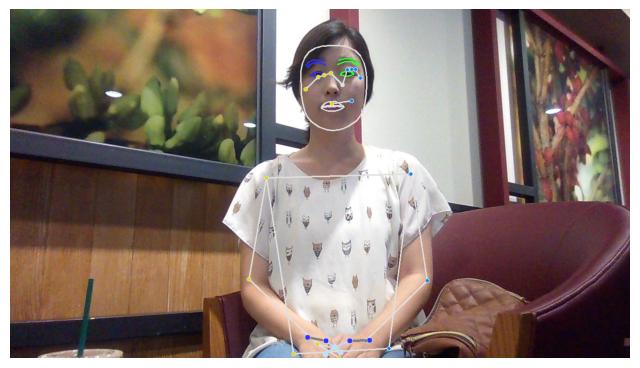

In [39]:
def draw_mediapipe_on_frame(
    video_path,
    frame_index=0,
    min_detection_confidence=0.4,
    min_tracking_confidence=0.4,
):
    """
    Processa um frame específico do vídeo e desenha landmarks sobre ele.
    Útil para inspeção visual.
    """
    video_path = Path(video_path)

    cap = cv2.VideoCapture(str(video_path))
    if not cap.isOpened():
        raise RuntimeError(f"Não foi possível abrir o vídeo: {video_path}")

    cap.set(cv2.CAP_PROP_POS_FRAMES, frame_index)
    success, frame_bgr = cap.read()
    cap.release()

    if not success:
        raise RuntimeError(f"Não foi possível ler o frame {frame_index} de {video_path}")

    frame_rgb = cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2RGB)

    with mp_holistic.Holistic(
        static_image_mode=True,
        model_complexity=1,
        refine_face_landmarks=False,
        min_detection_confidence=min_detection_confidence,
        min_tracking_confidence=min_tracking_confidence,
    ) as holistic:
        results = holistic.process(frame_rgb)

    annotated = frame_rgb.copy()

    # Face
    if results.face_landmarks:
        mp_drawing.draw_landmarks(
            annotated,
            results.face_landmarks,
            mp_holistic.FACEMESH_CONTOURS,
            landmark_drawing_spec=None,
            connection_drawing_spec=mp_drawing_styles.get_default_face_mesh_contours_style(),
        )

    # Pose
    if results.pose_landmarks:
        mp_drawing.draw_landmarks(
            annotated,
            results.pose_landmarks,
            mp_holistic.POSE_CONNECTIONS,
            landmark_drawing_spec=mp_drawing_styles.get_default_pose_landmarks_style(),
        )

    # Mãos
    if results.left_hand_landmarks:
        mp_drawing.draw_landmarks(
            annotated,
            results.left_hand_landmarks,
            mp_holistic.HAND_CONNECTIONS,
            landmark_drawing_spec=mp_drawing_styles.get_default_hand_landmarks_style(),
            connection_drawing_spec=mp_drawing_styles.get_default_hand_connections_style(),
        )

    if results.right_hand_landmarks:
        mp_drawing.draw_landmarks(
            annotated,
            results.right_hand_landmarks,
            mp_holistic.HAND_CONNECTIONS,
            landmark_drawing_spec=mp_drawing_styles.get_default_hand_landmarks_style(),
            connection_drawing_spec=mp_drawing_styles.get_default_hand_connections_style(),
        )

    return annotated


sample_video_path = Path(sample_row["video_path"])

annotated = draw_mediapipe_on_frame(
    sample_video_path,
    frame_index=0,
    min_detection_confidence=MIN_DETECTION_CONFIDENCE,
    min_tracking_confidence=MIN_TRACKING_CONFIDENCE,
)

plt.figure(figsize=(8, 8))
plt.imshow(annotated)
plt.axis("off")
plt.show()

## 13. Opcional: converter long-format para wide-format

In [ ]:
def long_to_wide_2d(df_long):
    """
    Converte o formato long para wide usando apenas x e y.

    Saída:
    uma linha por frame e colunas:
    face_000_x, face_000_y, ..., pose_000_x, pose_000_y, etc.

    Isso é útil se seu código de Skeleton-DML espera uma matriz temporal,
    com frames nas linhas e coordenadas nas colunas.
    """
    df = df_long.copy()

    df["landmark_name"] = (
        df["type"].astype(str)
        + "_"
        + df["landmark_index"].astype(int).astype(str).str.zfill(3)
    )

    x_wide = df.pivot_table(
        index="frame_id",
        columns="landmark_name",
        values="x",
        aggfunc="first",
    )

    y_wide = df.pivot_table(
        index="frame_id",
        columns="landmark_name",
        values="y",
        aggfunc="first",
    )

    x_wide.columns = [f"{col}_x" for col in x_wide.columns]
    y_wide.columns = [f"{col}_y" for col in y_wide.columns]

    wide = pd.concat([x_wide, y_wide], axis=1)

    # Ordena colunas para ficar x/y intercalado por landmark.
    ordered_cols = []
    landmark_names = sorted(df["landmark_name"].unique())

    for name in landmark_names:
        ordered_cols.append(f"{name}_x")
        ordered_cols.append(f"{name}_y")

    wide = wide.reindex(columns=ordered_cols)
    wide = wide.reset_index()

    return wide


df_wide_sample = long_to_wide_2d(df_sample)

display(df_wide_sample.head())
print("Shape wide:", df_wide_sample.shape)

In [ ]:
def save_wide_version_for_one_file(input_path, output_path, input_format="parquet"):
    """
    Converte um arquivo long para wide e salva.
    """
    input_path = Path(input_path)
    output_path = Path(output_path)
    output_path.parent.mkdir(parents=True, exist_ok=True)

    if input_format == "parquet":
        df_long = pd.read_parquet(input_path)
    else:
        df_long = pd.read_csv(input_path)

    df_wide = long_to_wide_2d(df_long)

    if output_path.suffix.lower() == ".parquet":
        df_wide.to_parquet(output_path, index=False)
    else:
        df_wide.to_csv(output_path, index=False)

    return df_wide


# Exemplo: salvar versão wide do arquivo de exemplo.
WIDE_DIR = OUTPUT_ROOT / "wide_2d_files"
WIDE_DIR.mkdir(parents=True, exist_ok=True)

wide_output_path = WIDE_DIR / sample_landmark_path.name
df_wide = save_wide_version_for_one_file(
    input_path=sample_landmark_path,
    output_path=wide_output_path,
    input_format=SAVE_FORMAT,
)

print("Wide salvo em:", wide_output_path)
display(df_wide.head())

## 14. Opcional: gerar wide-format para todo o KSL

In [ ]:
def convert_all_long_to_wide_2d(
    metadata,
    output_root,
    save_format="parquet",
    skip_existing=True,
):
    """
    Converte todos os arquivos long do metadata para wide 2D.
    """
    output_root = Path(output_root)
    wide_dir = output_root / "wide_2d_files"
    wide_dir.mkdir(parents=True, exist_ok=True)

    rows = []

    valid = metadata[metadata["status"].isin(["processed", "skipped_existing"])].copy()

    for _, row in tqdm(valid.iterrows(), total=len(valid), desc="Convertendo para wide"):
        input_path = output_root / row["path"]
        output_path = wide_dir / Path(row["path"]).name

        status = "converted"

        if skip_existing and output_path.exists():
            status = "skipped_existing"
        else:
            try:
                save_wide_version_for_one_file(
                    input_path=input_path,
                    output_path=output_path,
                    input_format=save_format,
                )
            except Exception as e:
                status = "error"
                print(f"Erro ao converter {input_path}: {e}")

        rows.append({
            "long_path": str(input_path.relative_to(output_root)),
            "wide_path": str(output_path.relative_to(output_root)),
            "video_name": row["video_name"],
            "sign": row["sign"],
            "signer_or_sample_id": row["signer_or_sample_id"],
            "sequence_id": row["sequence_id"],
            "status": status,
        })

    wide_metadata = pd.DataFrame(rows)
    wide_metadata_path = output_root / "metadata_ksl_wide_2d.csv"
    wide_metadata.to_csv(wide_metadata_path, index=False)

    print("Metadata wide salvo em:", wide_metadata_path)

    return wide_metadata


# Rode esta célula apenas se quiser gerar wide para todos os vídeos.
# Dependendo do tamanho do dataset, pode demorar e ocupar mais espaço.

# wide_metadata = convert_all_long_to_wide_2d(
#     metadata=metadata_ksl,
#     output_root=OUTPUT_ROOT,
#     save_format=SAVE_FORMAT,
#     skip_existing=True,
# )

# display(wide_metadata.head())

## 15. Opcional: compactar resultados

In [ ]:
# Útil no Colab para baixar ou mover os resultados.
# Rode se quiser gerar um .zip da pasta de saída.

# import shutil
# zip_path = shutil.make_archive(
#     base_name=str(OUTPUT_ROOT),
#     format="zip",
#     root_dir=str(OUTPUT_ROOT),
# )
# print("ZIP criado em:", zip_path)

## 16. Gerar um CSV único estilo MINDS com todos os vídeos 3D

Esta seção junta todos os arquivos individuais de landmarks em **um único CSV wide**, com uma linha por frame.

A diferença para o wide 2D anterior é que aqui entram `x`, `y` e `z`, além de:

- `sign`: nome textual do sinal, vindo do `ksl_class_label.p`;
- `sign_id`: classe/pasta do KSL (`01` até `77`);
- `interpreter`: identificador extraído do começo do arquivo (`00` até `19`);
- `missing_hand` e `missing_face`.

Os landmarks ausentes são preenchidos com `NaN`, mantendo a informação de ausência nas colunas `missing_*`.

In [48]:
# Ordem das colunas de landmarks no CSV final.
# Mãos primeiro para ficar visualmente parecido com o exemplo do MINDS.
WIDE_GROUP_ORDER = ["hand_0", "hand_1", "face", "pose"]


def expected_landmark_names(group_order=WIDE_GROUP_ORDER):
    names = []
    for group in group_order:
        for idx in range(LANDMARK_GROUPS[group]):
            names.append(f"{group}_{idx}")
    return names


def expected_wide_landmark_columns(coord_cols=("x", "y", "z"), group_order=WIDE_GROUP_ORDER):
    cols = []
    for name in expected_landmark_names(group_order):
        for coord in coord_cols:
            cols.append(f"{name}_{coord}")
    return cols


EXPECTED_WIDE_LANDMARK_COLUMNS = expected_wide_landmark_columns()

print("Total de colunas de landmarks:", len(EXPECTED_WIDE_LANDMARK_COLUMNS))
print(EXPECTED_WIDE_LANDMARK_COLUMNS[:12])

Total de colunas de landmarks: 1629
['hand_0_0_x', 'hand_0_0_y', 'hand_0_0_z', 'hand_0_1_x', 'hand_0_1_y', 'hand_0_1_z', 'hand_0_2_x', 'hand_0_2_y', 'hand_0_2_z', 'hand_0_3_x', 'hand_0_3_y', 'hand_0_3_z']


In [49]:
def read_landmark_file(file_path):
    file_path = Path(file_path)

    if file_path.suffix.lower() == ".parquet":
        return pd.read_parquet(file_path)

    if file_path.suffix.lower() == ".csv":
        return pd.read_csv(file_path)

    raise ValueError(f"Formato não suportado: {file_path}")


def long_to_wide_one_video(
    df_long,
    video_name=None,
    sign_id=None,
    sign=None,
    interpreter=None,
    class_labels=KSL_CLASS_LABELS,
    fill_missing_with_zero=FILL_MISSING_WITH_0,
):
    df = df_long.copy()

    if video_name is None:
        video_name = df["video_name"].iloc[0]

    parsed_sign_id, parsed_sign, parsed_interpreter = parse_ksl_info_from_video_name(
        video_name,
        class_labels=class_labels,
    )

    if sign_id is None or pd.isna(sign_id) or sign_id == "":
        sign_id = parsed_sign_id

    sign_id = str(sign_id).zfill(2)

    if sign is None or pd.isna(sign) or sign == "":
        sign = get_ksl_label(sign_id, class_labels)
        if sign == "":
            sign = parsed_sign

    if interpreter is None or pd.isna(interpreter) or interpreter == "":
        interpreter = parsed_interpreter

    interpreter = str(interpreter).zfill(2)

    df["landmark_name"] = (
        df["type"].astype(str)
        + "_"
        + df["landmark_index"].astype(int).astype(str)
    )

    # Calcula missing antes de substituir NaN por 0.
    missing_rows = []

    for frame_id, frame_df in df.groupby("frame_id"):
        hand_df = frame_df[frame_df["type"].isin(["hand_0", "hand_1"])]
        face_df = frame_df[frame_df["type"].eq("face")]

        missing_hand = hand_df[["x", "y"]].isna().any().any()
        missing_face = face_df[["x", "y"]].isna().any().any()

        missing_rows.append({
            "frame_id": frame_id,
            "missing_hand": bool(missing_hand),
            "missing_face": bool(missing_face),
        })

    missing_df = pd.DataFrame(missing_rows)

    expected_names = expected_landmark_names(WIDE_GROUP_ORDER)
    wide_parts = []

    for coord in ["x", "y", "z"]:
        pivot = df.pivot_table(
            index="frame_id",
            columns="landmark_name",
            values=coord,
            aggfunc="first",
        )

        # Garante que todos os 543 landmarks existam como colunas,
        # mesmo que algum ponto tenha ficado ausente no vídeo inteiro.
        pivot = pivot.reindex(columns=expected_names)
        pivot.columns = [f"{col}_{coord}" for col in pivot.columns]
        wide_parts.append(pivot)

    df_wide = pd.concat(wide_parts, axis=1).reset_index()

    # Reordena como landmark_x, landmark_y, landmark_z.
    df_wide = df_wide.reindex(columns=["frame_id"] + EXPECTED_WIDE_LANDMARK_COLUMNS)

    if fill_missing_with_zero:
        df_wide[EXPECTED_WIDE_LANDMARK_COLUMNS] = df_wide[EXPECTED_WIDE_LANDMARK_COLUMNS].fillna(0.0)

    # Metadados no começo.
    df_wide.insert(0, "video_name", video_name)
    df_wide.insert(0, "interpreter", interpreter)
    df_wide.insert(0, "sign_id", sign_id)
    df_wide.insert(0, "sign", sign)

    df_wide = df_wide.merge(missing_df, on="frame_id", how="left")
    df_wide["missing_hand"] = df_wide["missing_hand"].fillna(False).astype(bool)
    df_wide["missing_face"] = df_wide["missing_face"].fillna(False).astype(bool)

    return df_wide

In [50]:
def build_single_wide_csv_from_metadata(
    metadata_path,
    output_root,
    final_csv_path,
    class_labels=KSL_CLASS_LABELS,
    overwrite=True,
    fill_missing_with_zero=FILL_MISSING_WITH_0,
):
    metadata_path = Path(metadata_path)
    output_root = Path(output_root)
    final_csv_path = Path(final_csv_path)

    metadata = pd.read_csv(metadata_path)

    if overwrite and final_csv_path.exists():
        final_csv_path.unlink()

    first_write = True
    total_frames = 0
    processed_videos = 0
    skipped_videos = 0
    valid_status = {"processed", "skipped_existing"}

    for _, row in tqdm(metadata.iterrows(), total=len(metadata), desc="Gerando CSV wide único"):
        if "status" in metadata.columns and row["status"] not in valid_status:
            skipped_videos += 1
            continue

        landmark_path = output_root / row["path"]

        if not landmark_path.exists():
            print(f"Arquivo não encontrado: {landmark_path}")
            skipped_videos += 1
            continue

        df_long = read_landmark_file(landmark_path)

        video_name = row.get("video_name", df_long["video_name"].iloc[0])
        sign_id = row.get("sign_id", None)
        sign = row.get("sign", None)
        interpreter = row.get("interpreter", None)

        df_wide = long_to_wide_one_video(
            df_long=df_long,
            video_name=video_name,
            sign_id=sign_id,
            sign=sign,
            interpreter=interpreter,
            class_labels=class_labels,
            fill_missing_with_zero=fill_missing_with_zero,
        )

        df_wide.to_csv(
            final_csv_path,
            mode="w" if first_write else "a",
            header=first_write,
            index=False,
        )

        first_write = False
        total_frames += len(df_wide)
        processed_videos += 1

    print(f"CSV final salvo em: {final_csv_path}")
    print(f"Vídeos processados: {processed_videos}")
    print(f"Vídeos pulados: {skipped_videos}")
    print(f"Total de frames/linhas no CSV: {total_frames}")

    return final_csv_path

In [52]:
# Rode esta célula depois de extrair os landmarks e gerar metadata_ksl.csv.

final_csv_path = build_single_wide_csv_from_metadata(
    metadata_path=METADATA_PATH,
    output_root=OUTPUT_ROOT,
    final_csv_path=FINAL_WIDE_CSV_PATH,
    class_labels=KSL_CLASS_LABELS,
    overwrite=True,
    fill_missing_with_zero=FILL_MISSING_WITH_0,
)

Gerando CSV wide único:   0%|          | 0/1229 [00:00<?, ?it/s]

Gerando CSV wide único: 100%|██████████| 1229/1229 [05:11<00:00,  3.94it/s]

CSV final salvo em: /Users/dani/Projects/islr-subset/ksl_mediapipe/ksl_mediapipe_all_videos_wide.csv
Vídeos processados: 1229
Vídeos pulados: 0
Total de frames/linhas no CSV: 108373


## 17. Conferir o CSV final

In [53]:
# Lê só algumas linhas para não carregar o CSV inteiro se ele estiver muito grande.
df_final_preview = pd.read_csv(FINAL_WIDE_CSV_PATH, nrows=5)

display(df_final_preview)
print("Colunas:", len(df_final_preview.columns))
print("Primeiras colunas:", df_final_preview.columns[:20].tolist())
print("Últimas colunas:", df_final_preview.columns[-10:].tolist())

,sign,sign_id,interpreter,video_name,frame_id,hand_0_0_x,hand_0_0_y,hand_0_0_z,hand_0_1_x,hand_0_1_y,...,pose_30_y,pose_30_z,pose_31_x,pose_31_y,pose_31_z,pose_32_x,pose_32_y,pose_32_z,missing_hand,missing_face
0,hi,1,0,00_01.MP4,0,0.579847,0.949595,3.003216e-08,0.548328,0.950875,...,1.807853,0.250683,0.592675,1.871811,0.192679,0.480322,1.859148,-0.035175,False,False
1,hi,1,0,00_01.MP4,1,0.584365,0.939701,7.236433e-09,0.556417,0.934509,...,1.806839,0.235043,0.592683,1.870546,0.187968,0.482592,1.860547,-0.023532,False,False
2,hi,1,0,00_01.MP4,2,0.587292,0.941082,1.461811e-08,0.562637,0.935167,...,1.815134,0.361336,0.588037,1.882730,0.219705,0.481584,1.876135,0.101787,False,False
3,hi,1,0,00_01.MP4,3,NaN,NaN,NaN,NaN,NaN,...,1.822286,0.327419,0.588135,1.887973,0.225732,0.485177,1.886745,0.066725,True,False
4,hi,1,0,00_01.MP4,4,0.579403,0.945804,5.603964e-08,0.548517,0.948381,...,1.823570,0.322536,0.588245,1.888827,0.222679,0.485289,1.888130,0.063381,False,False


Colunas: 1636
Primeiras colunas: ['sign', 'sign_id', 'interpreter', 'video_name', 'frame_id', 'hand_0_0_x', 'hand_0_0_y', 'hand_0_0_z', 'hand_0_1_x', 'hand_0_1_y', 'hand_0_1_z', 'hand_0_2_x', 'hand_0_2_y', 'hand_0_2_z', 'hand_0_3_x', 'hand_0_3_y', 'hand_0_3_z', 'hand_0_4_x', 'hand_0_4_y', 'hand_0_4_z']
Últimas colunas: ['pose_30_y', 'pose_30_z', 'pose_31_x', 'pose_31_y', 'pose_31_z', 'pose_32_x', 'pose_32_y', 'pose_32_z', 'missing_hand', 'missing_face']


In [54]:
# Conferências úteis.
# Esta célula pode carregar o CSV inteiro; rode se o arquivo couber na memória.

df_final = pd.read_csv(FINAL_WIDE_CSV_PATH)
print(df_final.shape)
display(df_final[["sign", "sign_id", "interpreter", "video_name", "frame_id", "missing_hand", "missing_face"]].head())
display(df_final.groupby(["sign_id", "sign"])["video_name"].nunique().reset_index(name="num_videos"))
display(df_final["interpreter"].value_counts().sort_index())

(108373, 1636)


,sign,sign_id,interpreter,video_name,frame_id,missing_hand,missing_face
0,hi,1,0,00_01.MP4,0,False,False
1,hi,1,0,00_01.MP4,1,False,False
2,hi,1,0,00_01.MP4,2,False,False
3,hi,1,0,00_01.MP4,3,True,False
4,hi,1,0,00_01.MP4,4,False,False


,sign_id,sign,num_videos
0,1,hi,20
1,2,what,20
2,3,meat,20
3,4,bi bim rice,20
4,5,glad,19
...,...,...,...
62,71,food,14
63,72,want,19
64,74,one hour,20
65,76,good,20


0     6897
1     5250
2     4843
3     7226
4     4576
5     3376
6     3031
7     5468
8     4345
9     5613
10    6073
11    3376
12    4761
13    5831
14    6150
15    9090
16    9179
17    4824
18    2211
19    6253
Name: interpreter, dtype: int64

## 18. Opcional: salvar o CSV final também em Parquet

O CSV é bom para inspeção. Para treino, o Parquet costuma ser mais rápido e menor. Esta célula carrega o CSV inteiro em memória, então rode apenas se houver RAM suficiente.

In [55]:
FINAL_WIDE_PARQUET_PATH = OUTPUT_ROOT / "ksl_mediapipe_all_videos_wide.parquet"

df_final = pd.read_csv(FINAL_WIDE_CSV_PATH)
df_final.to_parquet(FINAL_WIDE_PARQUET_PATH, index=False)

print("Parquet final salvo em:", FINAL_WIDE_PARQUET_PATH)

Parquet final salvo em: /Users/dani/Projects/islr-subset/ksl_mediapipe/ksl_mediapipe_all_videos_wide.parquet


## Observações importantes

1. **Não altere o nome dos grupos** (`face`, `pose`, `hand_0`, `hand_1`) se o restante do seu pipeline já espera esses nomes.
2. `OUTPUT_ROOT` é a pasta geral do experimento; `LANDMARKS_DIR` guarda os arquivos individuais de landmarks.
3. O `metadata_ksl.csv` é sempre CSV e funciona como índice dos vídeos processados.
4. Os arquivos individuais em `landmark_files/` podem ser `.parquet` ou `.csv`, conforme `SAVE_FORMAT`.
5. O CSV final `ksl_mediapipe_all_videos_wide.csv` junta todos os vídeos, com uma linha por frame, no estilo do MINDS.
6. Pelo padrão dos nomes `00_01.MP4` até `19_01.MP4`, o notebook mantém `interpreter` como `00` a `19`. Se você quiser renomear para `01` a `20`, faça isso só depois de confirmar com a documentação do dataset.
7. Para o experimento principal com MediaPipe, use estes landmarks extraídos diretamente dos vídeos RGB, e não uma conversão de OpenPose para MediaPipe.